In [ ]:
!pip install scanpy anndata squidpy -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 4.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.8/87.8 kB 5.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.4/52.4 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 57.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.5/187.5 kB 19.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 280.5/280.5 kB 28.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.0/40.0 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.2/23.2 MB 88.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 127.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6

load datasets

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


load datasets

In [ ]:
import anndata as ad
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

adata_rna = ad.read_h5ad('/content/drive/MyDrive/IRBM/train_rna.h5ad')
adata_pro = ad.read_h5ad('/content/drive/MyDrive/IRBM/train_pro.h5ad')

print("RNA shape:", adata_rna.n_obs, "obs", adata_rna.n_vars, "genes")
print("Protein shape:", adata_pro.n_obs, "obs", adata_pro.n_vars, "proteins")

RNA shape: 166186 obs 18085 genes
Protein shape: 166186 obs 44 proteins


missing vals

In [ ]:
import scipy.sparse as sp

X_rna = adata_rna.X
X_pro = adata_pro.X

#check NaNs
print("MISSING VALUES")
if sp.issparse(X_rna):
    print(f"RNA NaN count: {np.isnan(X_rna.data).sum()}")
else:
    print(f"RNA NaN count: {np.isnan(X_rna).sum()}")

if sp.issparse(X_pro):
    print(f"Protein NaN count: {np.isnan(X_pro.data).sum()}")
else:
    print(f"Protein NaN count: {np.isnan(X_pro).sum()}")

#zeros
print("ZEROS")
if sp.issparse(X_rna):
    total_rna = X_rna.shape[0] * X_rna.shape[1]
    zeros_rna = total_rna - X_rna.nnz
    print(f"RNA zeros: {zeros_rna} ({zeros_rna/total_rna*100:.1f}%)")

if sp.issparse(X_pro):
    total_pro = X_pro.shape[0] * X_pro.shape[1]
    zeros_pro = total_pro - X_pro.nnz
    print(f"Protein zeros: {zeros_pro} ({zeros_pro/total_pro*100:.1f}%)")

#metadata
print("METADATA MISSING VALUES")
print("RNA obs:\n", adata_rna.obs.isnull().sum())
print("\nProtein obs:\n", adata_pro.obs.isnull().sum())

MISSING VALUES
RNA NaN count: 0
Protein NaN count: 0
ZEROS
RNA zeros: 2828070514 (94.1%)
METADATA MISSING VALUES
RNA obs:
 in_tissue             0
array_row             0
array_col             0
pxl_row_in_fullres    0
pxl_col_in_fullres    0
split                 0
dtype: int64

Protein obs:
 Series([], dtype: float64)


checking

In [ ]:
# Check protein matrix type and zeros
print("Protein matrix type:", type(adata_pro.X))
print("Protein value range:", adata_pro.X.min(), "to", adata_pro.X.max())

# If not sparse, check zeros directly
if not sp.issparse(adata_pro.X):
    zeros_pro = (adata_pro.X == 0).sum()
    total_pro = adata_pro.X.shape[0] * adata_pro.X.shape[1]
    print(f"Protein zeros: {zeros_pro} ({zeros_pro/total_pro*100:.1f}%)")

#list the 44 proteins names
print("\n44 proteins:", adata_pro.var_names.tolist())

#metadata columns
print("\nRNA obs sample:")
print(adata_rna.obs.head(3))

print("\nProtein obs sample:")
print(adata_pro.obs.head(3))

#embeddings/spatial coords
print("\nRNA obsm keys:", list(adata_rna.obsm.keys()))
print("Protein obsm keys:", list(adata_pro.obsm.keys()))

Protein matrix type: <class 'numpy.ndarray'>
Protein value range: 0.0 to 76675.51745972
Protein zeros: 13584 (0.2%)

44 proteins: ['synd', 'FOXP3', 'CD16', 'CD31', 'CXCL13', 'Ki67', 'OLIG2', 'CXCR5', 'HLA-A', 'PD-L1', 'PSD95', 'CD20', 'CD68', 'CD44', 'SMA', 'MSH6', 'CD23', 'GFAP', 'SYNA', 'Podoplanin', 'Vimentin', 'CD47', 'CD74', 'SIRP', 'Granzyme B', 'IDH1', 'MPO', 'CD45', 'CD21', 'FIBR', 'C-KIT', 'CD3e', 'TOX', 'PD-1', 'PDGFR', 'CD4', 'MAP2', 'CD8', 'MGMT', 'CD38', 'HLA-DR', 'CD14', 'ICOS', 'Granzyme K']

RNA obs sample:
                       in_tissue  array_row  array_col  pxl_row_in_fullres  \
s_016um_00059_00396-1          1         59        396         4440.653467   
s_016um_00331_00130-1          1        331        130         9431.361921   
s_016um_00014_00142-1          1         14        142         3678.192167   

                       pxl_col_in_fullres  split  
s_016um_00059_00396-1        28880.570188  train  
s_016um_00331_00130-1        33648.387158  train  
s_016

spattial coords

In [ ]:
#spatial coords from RNA obs
coords = adata_rna.obs[['pxl_col_in_fullres', 'pxl_row_in_fullres']].values
print("Spatial coords shape:", coords.shape)
print("Sample coords:", coords[:3])

# Check if spot IDs match between RNA and proteins
rna_spots = set(adata_rna.obs.index)
pro_spots  = set(adata_pro.obs.index)

print(f"\nRNA spots:     {len(rna_spots)}")
print(f"Protein spots: {len(pro_spots)}")
print(f"Spots in both: {len(rna_spots & pro_spots)}")
print(f"Only in RNA:   {len(rna_spots - pro_spots)}")
print(f"Only in protein: {len(pro_spots - rna_spots)}")

Spatial coords shape: (166186, 2)
Sample coords: [[28880.57018842  4440.65346735]
 [33648.38715785  9431.36192117]
 [33497.80753424  3678.19216674]]

RNA spots:     166186
Protein spots: 166186
Spots in both: 166186
Only in RNA:   0
Only in protein: 0


look

RNA spots: 166186
Protein spots: 166186
Order matches: True


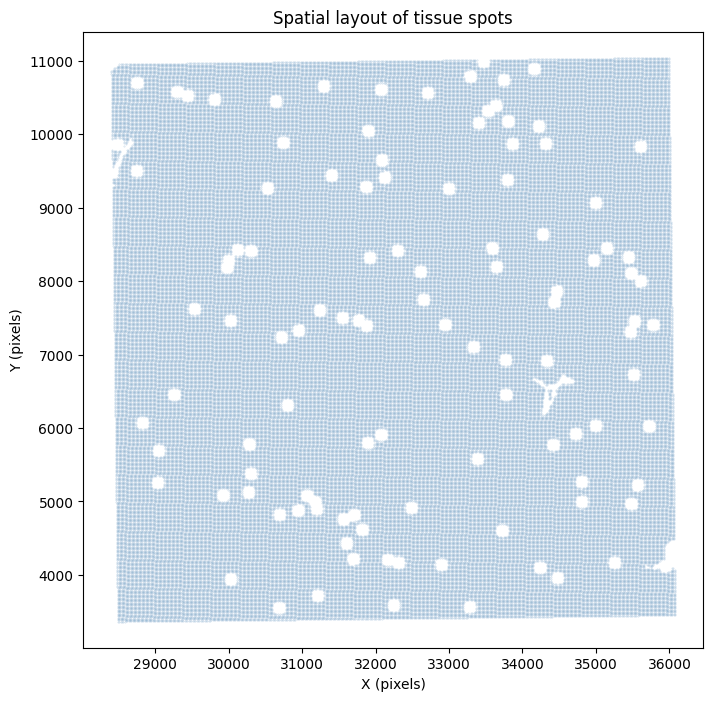

In [ ]:
#align protein to RNA row order
adata_pro_aligned = adata_pro[adata_rna.obs.index, :]

#check
print("RNA spots:",     adata_rna.n_obs)
print("Protein spots:", adata_pro_aligned.n_obs)
print("Order matches:", (adata_rna.obs.index == adata_pro_aligned.obs.index).all())

#spatial plot
plt.figure(figsize=(8, 8))
plt.scatter(coords[:, 0], coords[:, 1], s=0.1, alpha=0.3, c='steelblue')
plt.title('Spatial layout of tissue spots')
plt.xlabel('X (pixels)')
plt.ylabel('Y (pixels)')
plt.axis('equal')
plt.show()

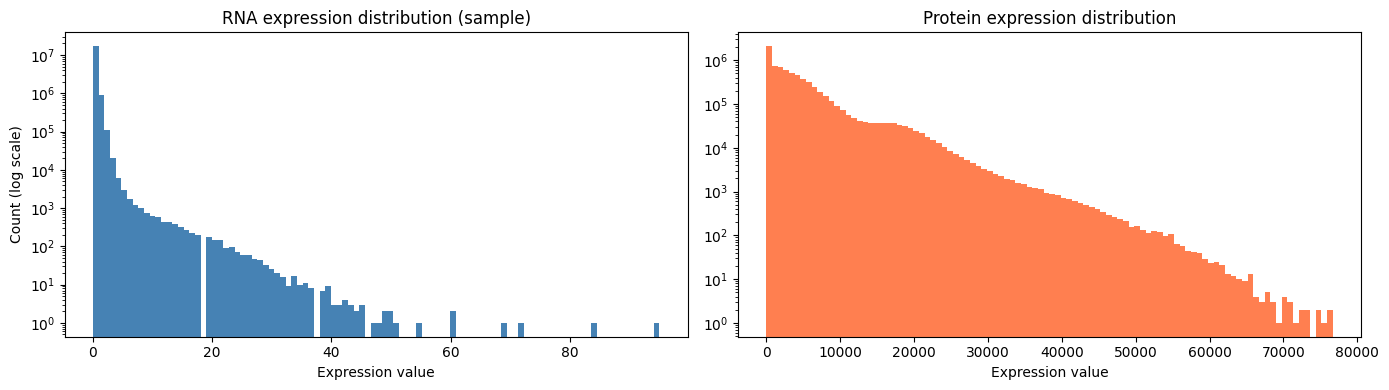

RNA value range: 0.0 to 95.0
Protein value range: 0.0 to 76675.51745972
RNA values are integers: True


In [ ]:
import scipy.sparse as sp

#RNA sample
rna_sample = adata_rna.X[:1000]
if sp.issparse(rna_sample):
    rna_sample = rna_sample.toarray()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

#RNA distribution
axes[0].hist(rna_sample.flatten(), bins=100, color='steelblue', log=True)
axes[0].set_title('RNA expression distribution (sample)')
axes[0].set_xlabel('Expression value')
axes[0].set_ylabel('Count (log scale)')

#protein distr (uses all data)
axes[1].hist(adata_pro.X.flatten(), bins=100, color='coral', log=True)
axes[1].set_title('Protein expression distribution')
axes[1].set_xlabel('Expression value')

plt.tight_layout()
plt.show()

#stats
print("RNA value range:", adata_rna.X[:1000].min(), "to", adata_rna.X[:1000].max())
print("Protein value range:", adata_pro.X.min(), "to", adata_pro.X.max())

#RNA values type
if sp.issparse(adata_rna.X):
    vals = adata_rna.X.data[:1000]
else:
    vals = adata_rna.X.flatten()[:1000]
print("RNA values are integers:", np.all(vals == vals.astype(int)))

# PREPROCESSING NOTES:
# RNA: already normalised (range 0-95, integers), but log1p transform still recommended
# Protein: raw fluorescence intensities (range 0-76675), needs normalisation before modelling
# Both are heavily right-skewed — log transformation

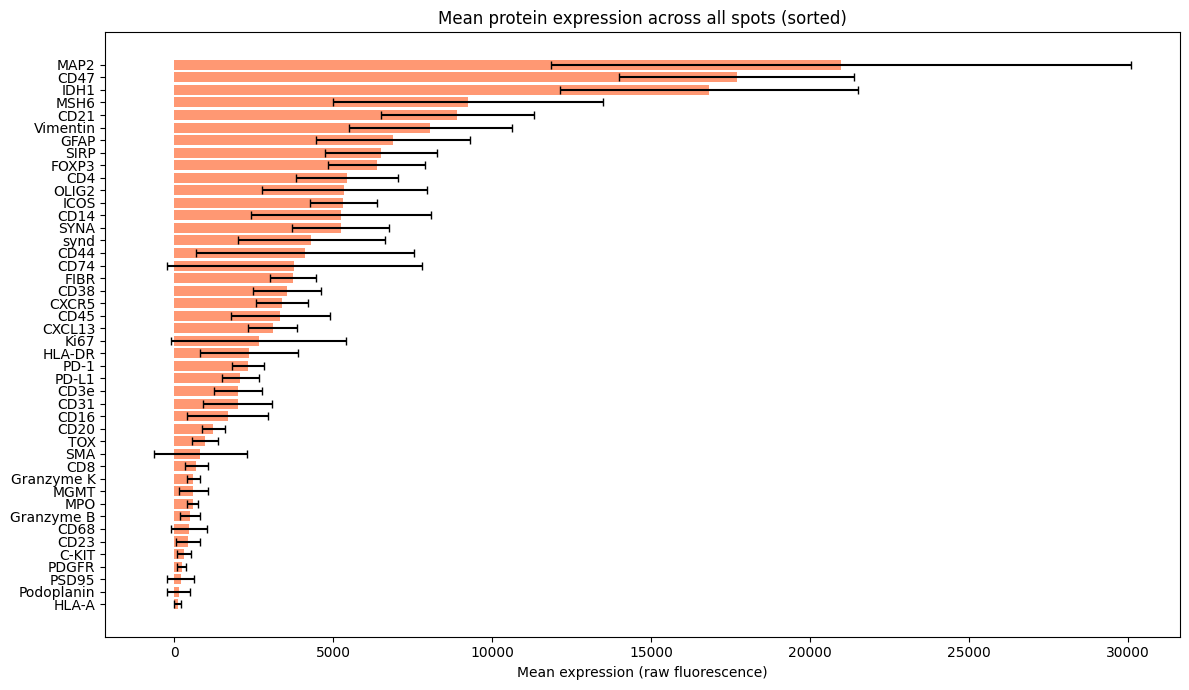

TOP 5 most expressed proteins:
  MAP2                 mean=20968.1
  CD47                 mean=17683.6
  IDH1                 mean=16815.7
  MSH6                 mean=9228.1
  CD21                 mean=8902.9

BOTTOM 5 least expressed proteins:
  C-KIT                mean=288.3
  PDGFR                mean=230.7
  PSD95                mean=196.3
  Podoplanin           mean=130.3
  HLA-A                mean=98.0


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

protein_names = adata_pro.var_names.tolist()
X_pro = adata_pro.X

#mean and std per protein
protein_means = X_pro.mean(axis=0)
protein_stds  = X_pro.std(axis=0)

#sort by mean expression
sort_idx = np.argsort(protein_means)[::-1]
sorted_names  = [protein_names[i] for i in sort_idx]
sorted_means  = protein_means[sort_idx]
sorted_stds   = protein_stds[sort_idx]

#bar plot
fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(sorted_names, sorted_means, xerr=sorted_stds,
               color='coral', alpha=0.8, capsize=3)
ax.set_xlabel('Mean expression (raw fluorescence)')
ax.set_title('Mean protein expression across all spots (sorted)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

#top & bottom 5
print("TOP 5 most expressed proteins:")
for i in range(5):
    print(f"  {sorted_names[i]:<20} mean={sorted_means[i]:.1f}")

print("\nBOTTOM 5 least expressed proteins:")
for i in range(-5, 0):
    print(f"  {sorted_names[i]:<20} mean={sorted_means[i]:.1f}")

closer look

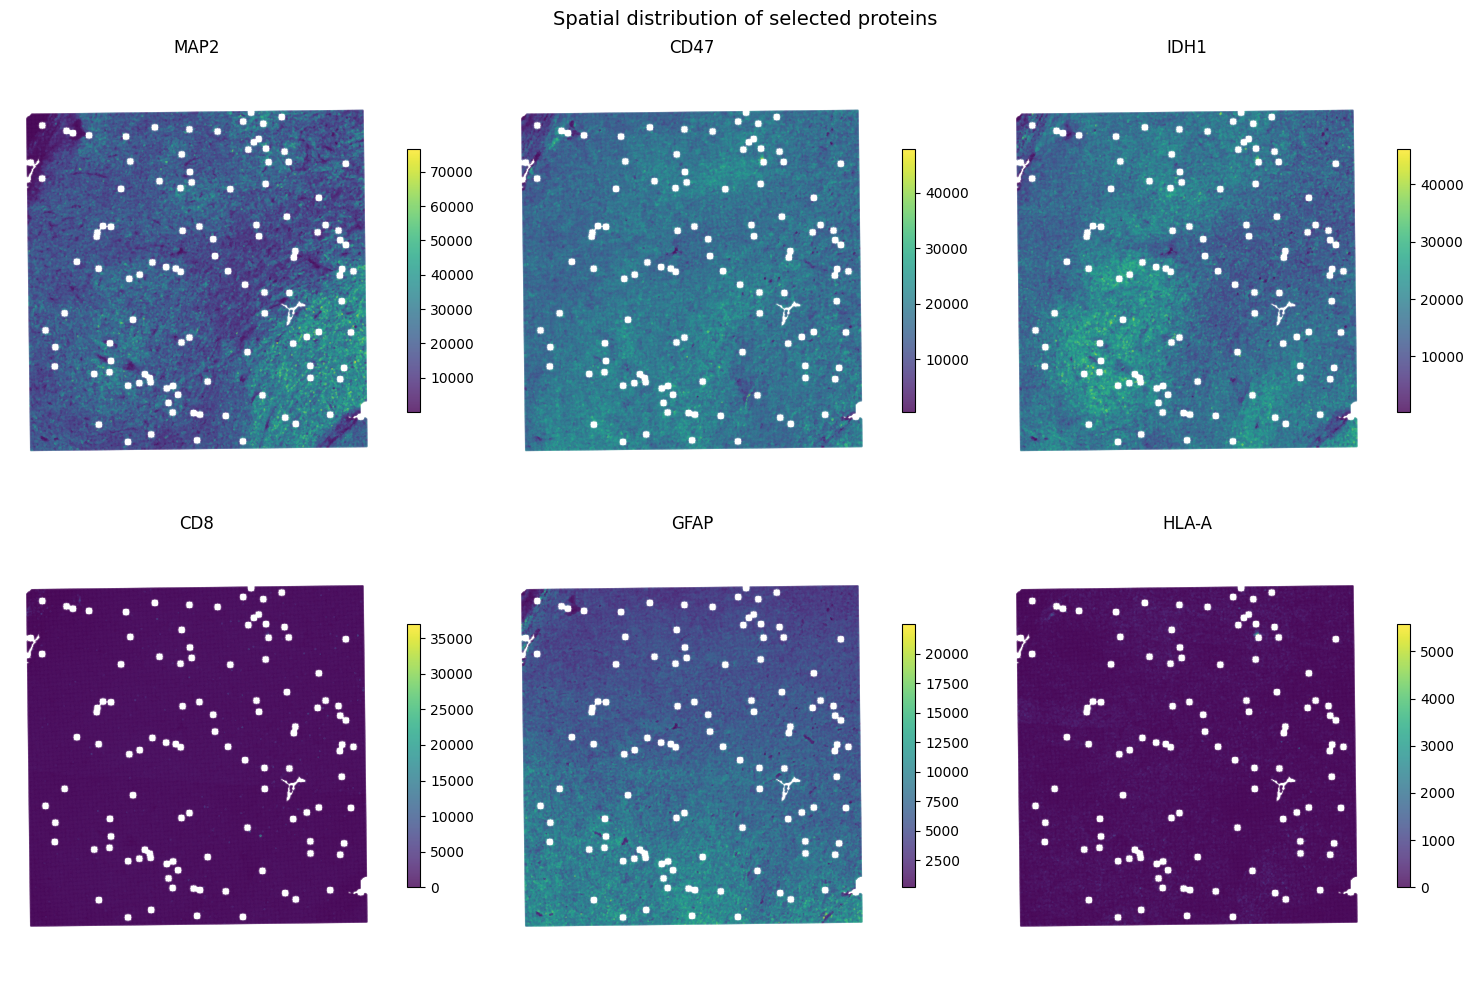

In [ ]:
#visualise the 6 proteins
proteins_to_plot = ['MAP2', 'CD47', 'IDH1', 'CD8', 'GFAP', 'HLA-A']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, protein in enumerate(proteins_to_plot):
    idx = protein_names.index(protein)
    vals = X_pro[:, idx]

    sc = axes[i].scatter(coords[:, 0], coords[:, 1],
                         c=vals, cmap='viridis', s=0.1, alpha=0.8)
    plt.colorbar(sc, ax=axes[i], shrink=0.6)
    axes[i].set_title(protein)
    axes[i].axis('equal')
    axes[i].axis('off')

plt.suptitle('Spatial distribution of selected proteins', fontsize=14)
plt.tight_layout()
plt.show()

protein analysis

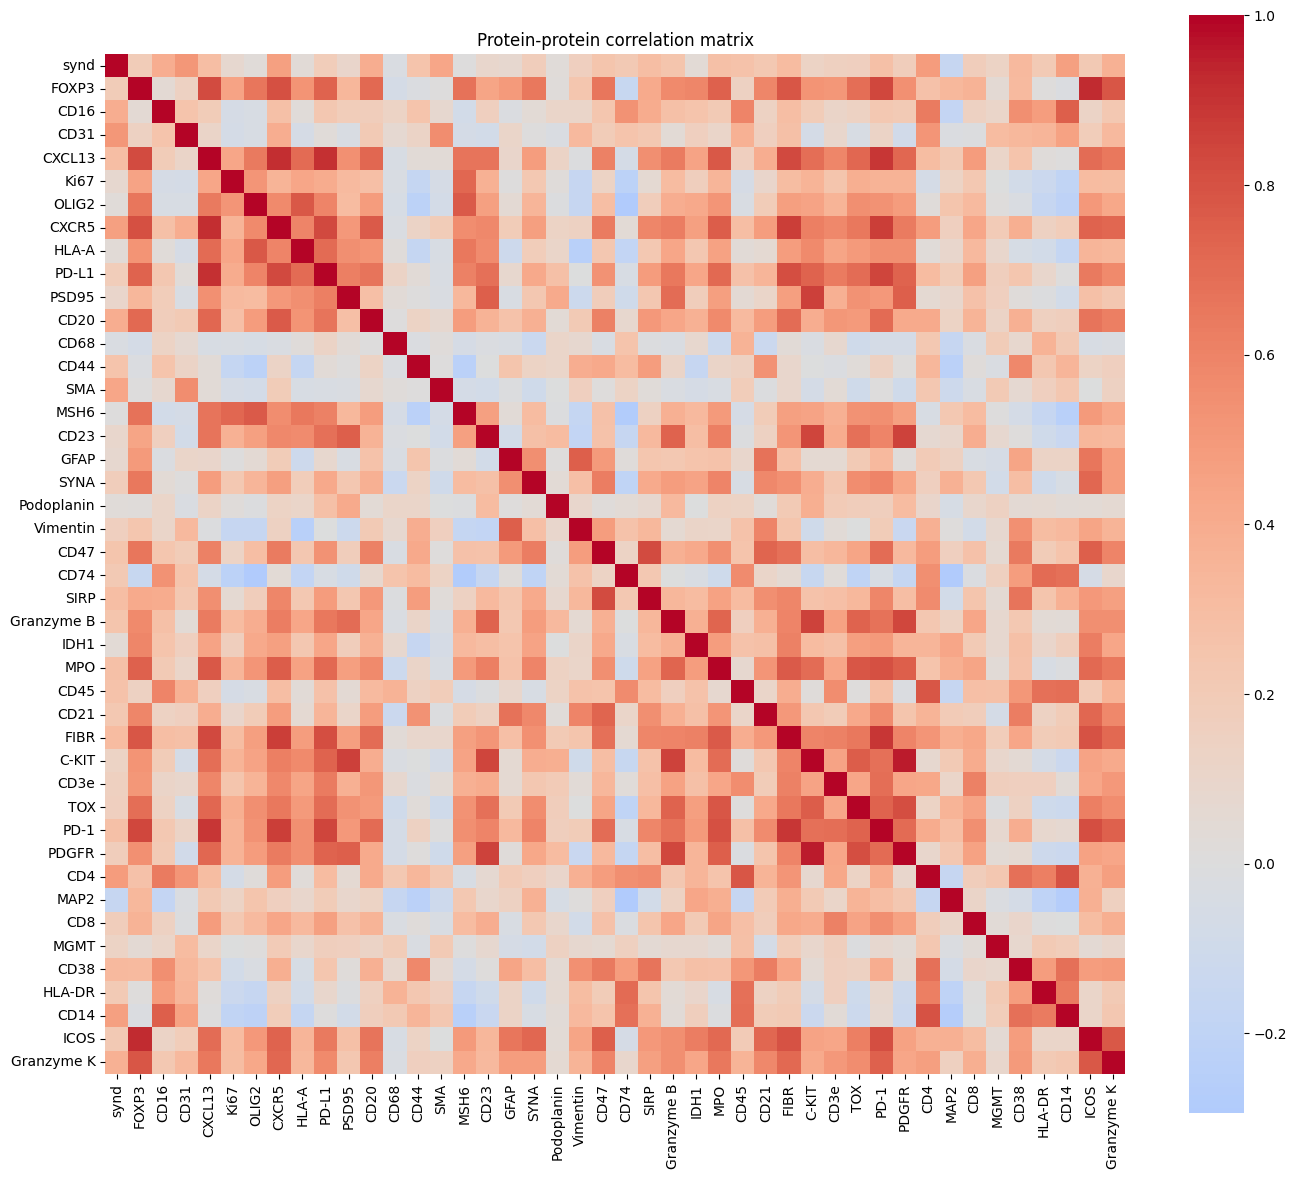

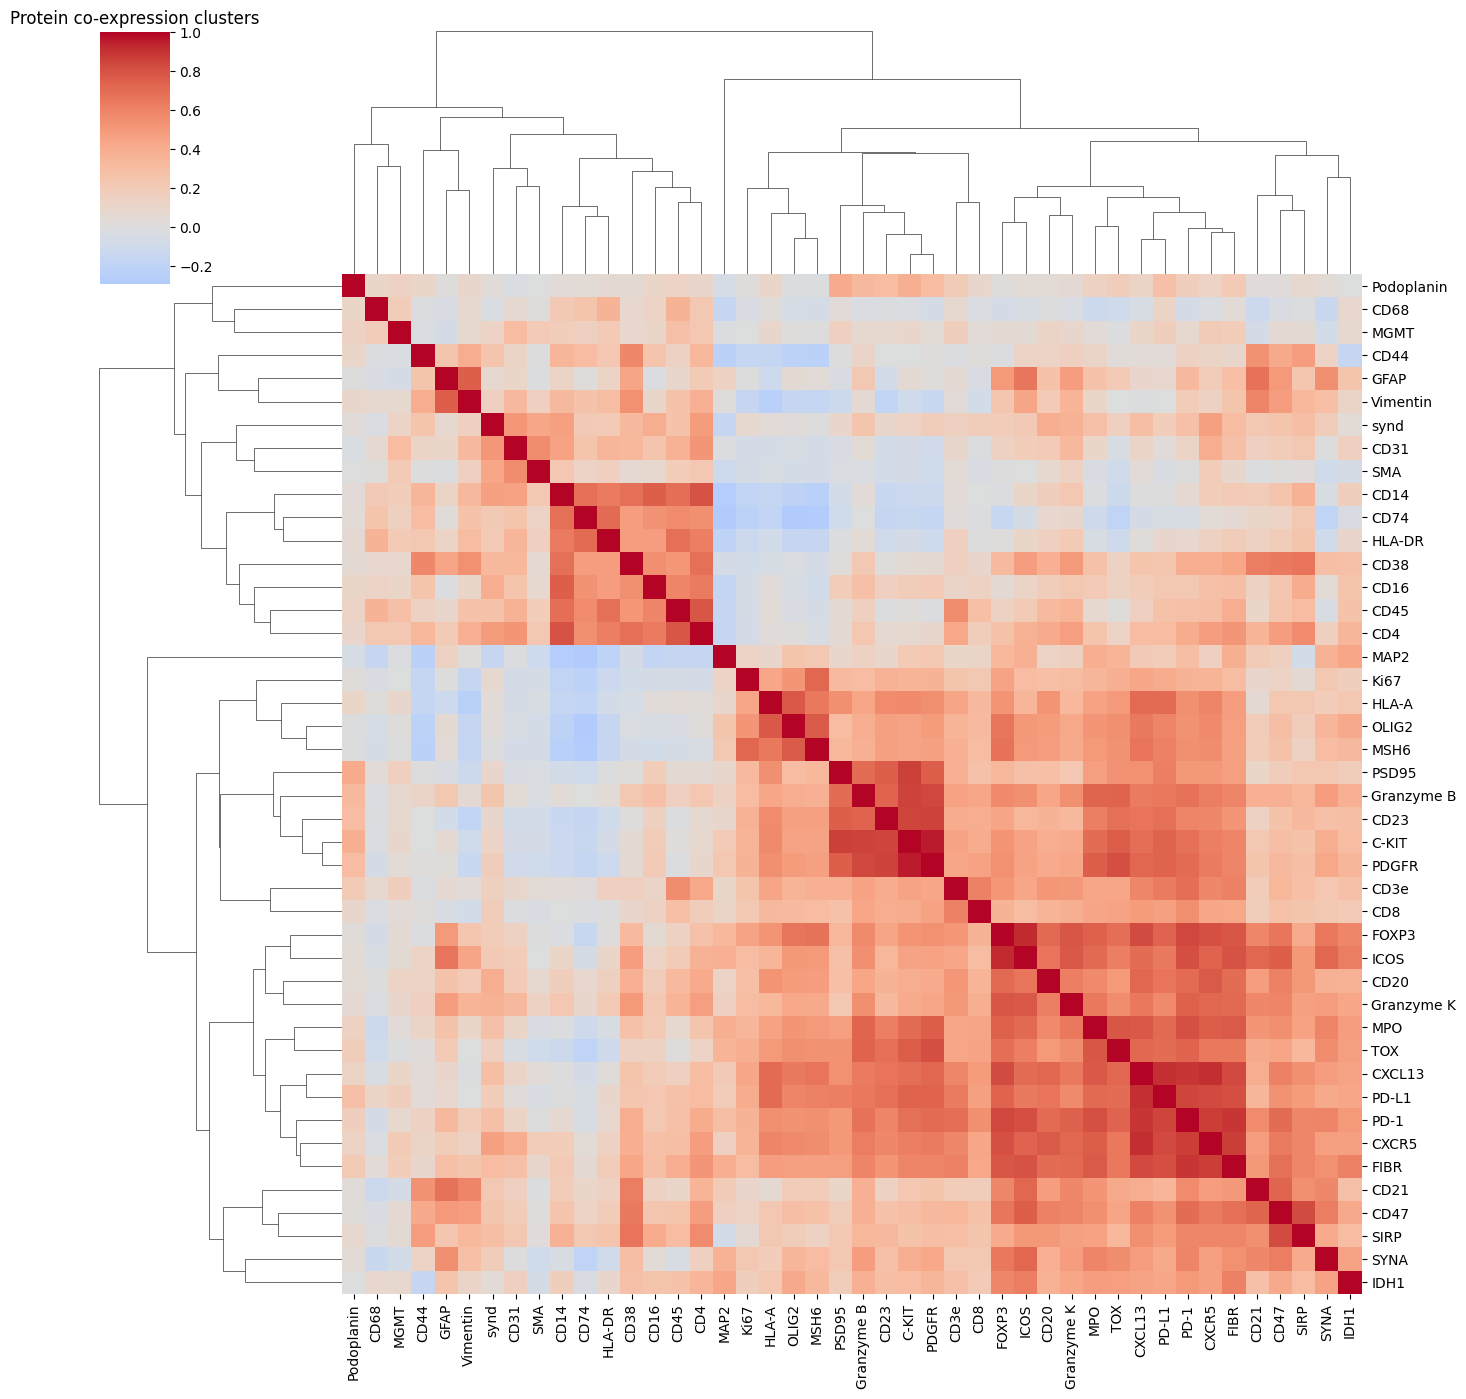

In [ ]:
import seaborn as sns

df_pro = pd.DataFrame(adata_pro.X, columns=protein_names)
corr_matrix = df_pro.corr()

plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0,
            xticklabels=True, yticklabels=True,
            annot=False, square=True)
plt.title('Protein-protein correlation matrix')
plt.tight_layout()
plt.show()

sns.clustermap(corr_matrix,
               cmap='coolwarm',
               center=0,
               figsize=(14, 14),
               annot=False)
plt.title('Protein co-expression clusters')
plt.show()

In [ ]:
!pip install leidenalg igraph -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 48.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 137.3 MB/s eta 0:00:00


clustering

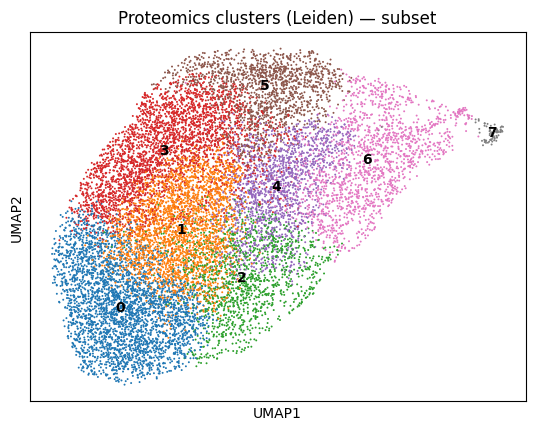

In [ ]:
# work on a subset
n_subset = 15000

np.random.seed(42)
subset_idx = np.random.choice(adata_rna.n_obs, n_subset, replace=False)

adata_rna_sub = adata_rna[subset_idx].copy()
adata_pro_sub = adata_pro[subset_idx].copy()

# preprocessing pipeline — use adata_pro_sub, not adata_pro_sc
sc.pp.normalize_total(adata_pro_sub)
sc.pp.log1p(adata_pro_sub)
sc.pp.pca(adata_pro_sub)
sc.pp.neighbors(adata_pro_sub)
sc.tl.umap(adata_pro_sub)
sc.tl.leiden(adata_pro_sub, resolution=0.5, flavor='igraph', n_iterations=2, directed=False)

# Plot UMAP coloured by cluster
sc.pl.umap(adata_pro_sub, color='leiden',
           title='Proteomics clusters (Leiden) — subset',
           legend_loc='on data')

LEIDEN CLUSTERING
- https://medium.com/@swapnil.agashe456/leiden-clustering-for-community-detection-a-step-by-step-guide-with-python-implementation-c883933a1430
- https://neo4j.com/docs/graph-data-science/current/algorithms/leiden/
- https://scanpy.readthedocs.io/en/stable/generated/scanpy.tl.leiden.html
- https://docs.platforma.bio/guides/sc-rna-seq-analysis/leiden-clustering/

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.multioutput import MultiOutputRegressor

model = MultiOutputRegressor(Ridge(alpha=1.0))
model.fit(X_train_rna, X_train_pro)  # predicts all 44 proteins at once

NameError: name 'X_train_rna' is not defined

In [ ]:
import numpy as np
import pandas as pd
from sklearn.linear_model import Lasso
from sklearn.multioutput import MultiOutputRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
import scipy.sparse as sp

# ---------------------------------------------------------
# 1. Subsample spots (memory-safe)
# ---------------------------------------------------------
n_subset = 15000

np.random.seed(42)
subset_idx = np.random.choice(adata_rna.n_obs, n_subset, replace=False)

adata_rna_sub = adata_rna[subset_idx].copy()
adata_pro_sub = adata_pro[subset_idx].copy()

print("RNA subset shape:", adata_rna_sub.shape)
print("Protein subset shape:", adata_pro_sub.shape)

# Extract matrices
X = adata_rna_sub.X
X = X.toarray() if sp.issparse(X) else np.asarray(X)

y = adata_pro_sub.X
y = y.toarray() if sp.issparse(y) else np.asarray(y)

print("X (genes) shape:", X.shape)
print("y (proteins) shape:", y.shape)

# Train/test split (within the subset)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#  Scale features — Lasso penalises
#  coefficient magnitude, and genes (diff scales)
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled  = scaler_X.transform(X_test)

scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train)
y_test_scaled  = scaler_y.transform(y_test)

# Train Lasso (multi-output: one Lasso model per protein)
lasso_model = MultiOutputRegressor(
    Lasso(alpha=0.01, max_iter=5000),
    n_jobs=-1  # parallelise across the 44 proteins
)

lasso_model.fit(X_train_scaled, y_train_scaled)

#  Evaluate
y_pred_scaled = lasso_model.predict(X_test_scaled)

r2_per_protein = r2_score(y_test_scaled, y_pred_scaled, multioutput='raw_values')
protein_names = adata_pro.var_names.tolist()

df_results = pd.DataFrame({
    'protein': protein_names,
    'r2_score': r2_per_protein
}).sort_values('r2_score', ascending=False)

print("\n=== Lasso R² per protein (top 10) ===")
print(df_results.head(10).to_string(index=False))

print("\n=== Lasso R² per protein (bottom 10) ===")
print(df_results.tail(10).to_string(index=False))

print(f"\nMean R² across all 44 proteins: {r2_per_protein.mean():.3f}")

RNA subset shape: (15000, 18085)
Protein subset shape: (15000, 44)
X (genes) shape: (15000, 18085)
y (proteins) shape: (15000, 44)


In [ ]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
import scipy.sparse as sp

n_subset = 15000

np.random.seed(42)
subset_idx = np.random.choice(adata_rna.n_obs, n_subset, replace=False)

adata_rna_sub = adata_rna[subset_idx].copy()
adata_pro_sub = adata_pro[subset_idx].copy()

print("RNA subset shape:", adata_rna_sub.shape)
print("Protein subset shape:", adata_pro_sub.shape)


X = adata_rna_sub.X
X = X.toarray() if sp.issparse(X) else np.asarray(X)

y = adata_pro_sub.X
y = y.toarray() if sp.issparse(y) else np.asarray(y)


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled  = scaler_X.transform(X_test)

gene_variances = X_train_scaled.var(axis=0)
top_gene_idx   = np.argsort(gene_variances)[::-1][:2000]

X_train_reduced = X_train_scaled[:, top_gene_idx]
X_test_reduced  = X_test_scaled[:, top_gene_idx]

print(f"Using top 2000 most variable genes out of {X_train_scaled.shape[1]}")

rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    max_features='sqrt',
    n_jobs=-1,
    random_state=42
)

rf_model.fit(X_train_reduced, y_train)

y_pred = rf_model.predict(X_test_reduced)

r2_per_protein = r2_score(y_test, y_pred, multioutput='raw_values')
protein_names  = adata_pro.var_names.tolist()

df_results = pd.DataFrame({
    'protein':  protein_names,
    'r2_score': r2_per_protein
}).sort_values('r2_score', ascending=False)

print("\n=== Random Forest R² per protein (top 10) ===")
print(df_results.head(10).to_string(index=False))

print("\n=== Random Forest R² per protein (bottom 10) ===")
print(df_results.tail(10).to_string(index=False))

print(f"\nMean R² across all 44 proteins: {r2_per_protein.mean():.3f}")

from sklearn.model_selection import cross_val_score, KFold

kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf_model, X_train_reduced, y_train, cv=kf, scoring='r2')

print("\n=== 5-Fold Cross-Validation ===")
print("CV R² scores:", cv_scores)
print(f"Mean CV R²: {cv_scores.mean():.3f}")
print(f"Std CV R²:  {cv_scores.std():.3f}")


importances     = rf_model.feature_importances_
top_import_idx  = np.argsort(importances)[::-1][:20]
top_gene_names  = adata_rna.var_names[top_gene_idx][top_import_idx]
top_importances = importances[top_import_idx]

plt.figure(figsize=(10, 6))
plt.barh(top_gene_names[::-1], top_importances[::-1], color='steelblue')
plt.xlabel('Feature importance')
plt.title('Top 20 genes driving protein predictions (Random Forest)')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,5))
plt.hist(r2_per_protein, bins=20, color='steelblue', edgecolor='black')
plt.axvline(0, color='red', linestyle='--')
plt.xlabel('R² score')
plt.ylabel('Number of proteins')
plt.title('Distribution of R² scores across all 44 proteins')
plt.show()

best_protein = df_results.iloc[0]['protein']
protein_idx = protein_names.index(best_protein)

plt.figure(figsize=(6,6))
plt.scatter(y_test[:, protein_idx], y_pred[:, protein_idx], s=5, alpha=0.4)
plt.plot([y_test[:,protein_idx].min(), y_test[:,protein_idx].max()],
         [y_test[:,protein_idx].min(), y_test[:,protein_idx].max()],
         'r--', label='Perfect prediction')
plt.xlabel(f'Actual {best_protein} expression')
plt.ylabel(f'Predicted {best_protein} expression')
plt.title(f'Random Forest: Actual vs Predicted ({best_protein})')
plt.legend()
plt.show()

RNA subset shape: (10000, 18085)
Protein subset shape: (10000, 44)


KeyboardInterrupt: 

In [ ]:
!pip install igraph -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 53.9 MB/s eta 0:00:00


In [ ]:
import os
import json
import numpy as np
import anndata as ad
from sklearn.model_selection import KFold

# create output folder
os.makedirs('/content/drive/MyDrive/IRBM/outputs', exist_ok=True)

def cv_split(rna_path, output_path, n_splits=5, random_state=42):
    rna_data = ad.read_h5ad(rna_path)
    n_bins = rna_data.n_obs
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    splits = []
    for fold, (train_idx, test_idx) in enumerate(kf.split(np.arange(n_bins))):
        splits.append({
            "fold": fold,
            "train": train_idx.tolist(),
            "test":  test_idx.tolist(),
        })
    split_path = f"{output_path}/cv_splits.json"
    with open(split_path, "w") as f:
        json.dump({
            "n_splits":     n_splits,
            "n_bins":       n_bins,
            "random_state": random_state,
            "splits":       splits,
        }, f)
    info_path = f"{output_path}/cv_splits_info.txt"
    with open(info_path, "w") as f:
        f.write(f"CV split summary\n{'='*40}\n")
        f.write(f"n_bins       : {n_bins:,}\n")
        f.write(f"n_splits     : {n_splits}\n")
        f.write(f"random_state : {random_state}\n\n")
        for s in splits:
            f.write(f"Fold {s['fold']+1}: {len(s['train']):,} train | {len(s['test']):,} test\n")
    print(f"Splits saved to {split_path}")
    return splits

def load_cv_split(split_path):
    with open(split_path, "r") as f:
        data = json.load(f)
    return data["splits"]

# Generate splits on subset
# save the subset as a temporary h5ad
adata_rna_sub.write_h5ad('/content/drive/MyDrive/IRBM/outputs/rna_sub.h5ad')

splits = cv_split(
    rna_path='/content/drive/MyDrive/IRBM/outputs/rna_sub.h5ad',
    output_path='/content/drive/MyDrive/IRBM/outputs'
)

Splits saved to /content/drive/MyDrive/IRBM/outputs/cv_splits.json


INFO     Creating graph using `None` transform and `1` libraries.                                                  
Spatial Leiden clusters:
leiden
0    2972
1    2157
2    1720
4    1718
3    1378
5      55
Name: count, dtype: int64


/tmp/ipykernel_984/283089055.py:58: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', len(unique_clusters))


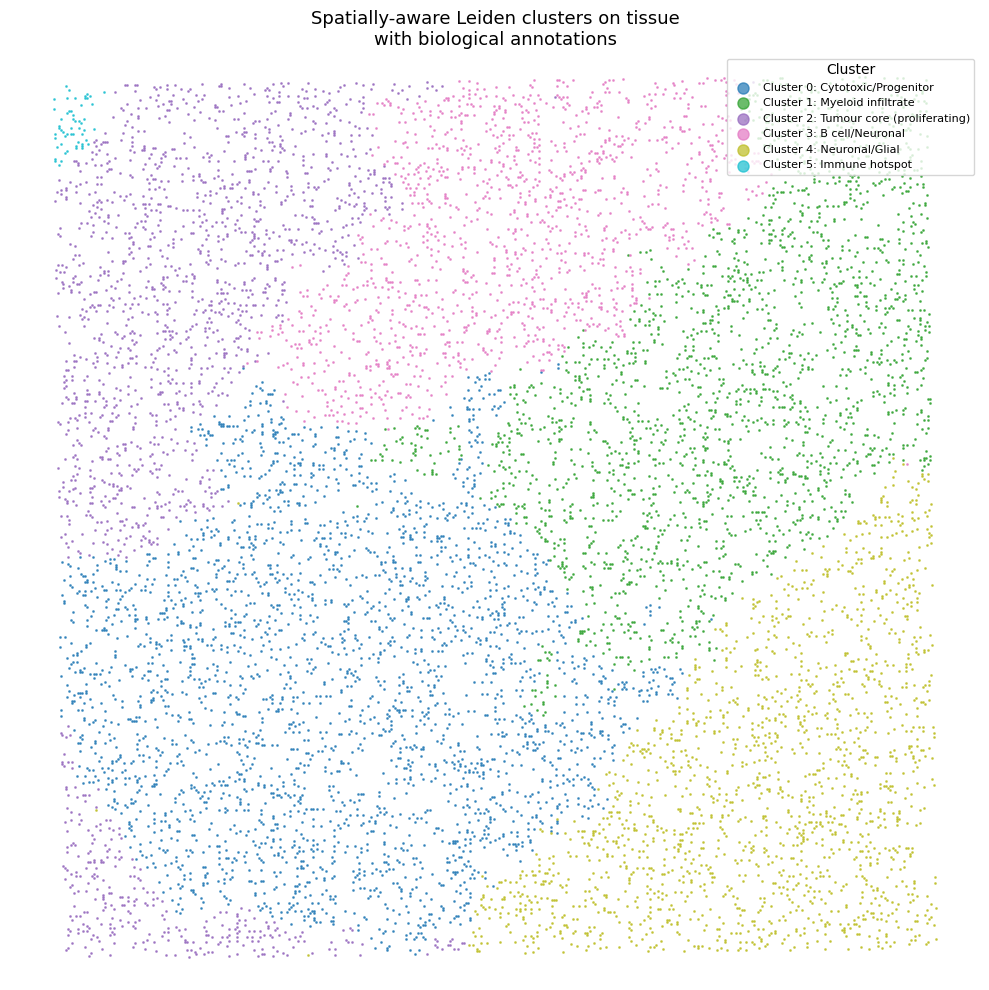

In [ ]:
import scanpy as scanpy_lib
import squidpy as sq
import scipy.sparse as sp
import matplotlib.pyplot as plt
import numpy as np

adata_pro_spatial = adata_pro_sub.copy()
cluster_names = {
    '0': 'Cytotoxic/Progenitor',
    '1': 'Myeloid infiltrate',
    '2': 'Tumour core (proliferating)',
    '3': 'B cell/Neuronal',
    '4': 'Neuronal/Glial',
    '5': 'Immune hotspot'
}

# Add spatial coordinates
adata_pro_spatial.obsm['spatial'] = adata_rna_sub.obs[[
    'pxl_col_in_fullres',
    'pxl_row_in_fullres'
]].values

# Normalise and PCA
scanpy_lib.pp.normalize_total(adata_pro_spatial)
scanpy_lib.pp.log1p(adata_pro_spatial)
scanpy_lib.pp.pca(adata_pro_spatial)

# Build expression neighbour graph
scanpy_lib.pp.neighbors(adata_pro_spatial, n_neighbors=15)

# Build spatial neighbour graph
sq.gr.spatial_neighbors_knn(adata_pro_spatial, n_neighs=6)

# Combine both graphs
expr_graph    = adata_pro_spatial.obsp['connectivities']
spatial_graph = adata_pro_spatial.obsp['spatial_connectivities']
combined_graph = 0.5 * expr_graph + 0.5 * spatial_graph
adata_pro_spatial.obsp['connectivities'] = combined_graph

# Leiden on combined graph
scanpy_lib.tl.leiden(adata_pro_spatial,
                     resolution=0.5,
                     flavor='igraph',
                     n_iterations=2,
                     directed=False)

cluster_labels_spatial = adata_pro_spatial.obs['leiden'].values
print("Spatial Leiden clusters:")
print(adata_pro_spatial.obs['leiden'].value_counts())

# Plot
coords_sub = adata_rna_sub.obs[[
    'pxl_col_in_fullres',
    'pxl_row_in_fullres'
]].values

unique_clusters = sorted(adata_pro_spatial.obs['leiden'].unique(), key=lambda x: int(x))
cmap = plt.cm.get_cmap('tab10', len(unique_clusters))

plt.figure(figsize=(10, 10))
for i, cluster in enumerate(unique_clusters):
    mask = cluster_labels_spatial == cluster
    label = f"Cluster {cluster}: {cluster_names[cluster]}"
    plt.scatter(coords_sub[mask, 0], coords_sub[mask, 1],
                c=[cmap(i)], s=1, alpha=0.7, label=label)

plt.title('Spatially-aware Leiden clusters on tissue\nwith biological annotations', fontsize=13)
plt.axis('equal')
plt.axis('off')
plt.legend(markerscale=8, loc='upper right',
           title='Cluster', fontsize=8)
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import scanpy as sc
import squidpy as sq
import scipy.sparse as sp

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.decomposition import PCA

# Subsample
n_subset = 15000

np.random.seed(42)
subset_idx = np.random.choice(adata_rna.n_obs, n_subset, replace=False)

adata_rna_sub = adata_rna[subset_idx].copy()
adata_pro_sub = adata_pro[subset_idx].copy()

print(f"RNA subset:     {adata_rna_sub.shape}")
print(f"Protein subset: {adata_pro_sub.shape}")

# Add spatial coordinates to RNA subset
adata_rna_sub.obsm['spatial'] = adata_rna_sub.obs[[
    'pxl_col_in_fullres',
    'pxl_row_in_fullres'
]].values

# Build spatial neighbour graph
# n_neighs=6 = each spot looks at 6 nearest neighbours
sq.gr.spatial_neighbors_knn(adata_rna_sub,
                             n_neighs=6)

print("Spatial neighbour graph built")

# Compute neighbour-averaged RNA expression
# For each spot, average its neighbours' gene expression
# (spatial context feature)
X_rna = adata_rna_sub.X
X_rna = X_rna.toarray() if sp.issparse(X_rna) else np.asarray(X_rna)

# Get adjacency matrix from squidpy
adj = adata_rna_sub.obsp['spatial_connectivities']

# Row-normalise so each row sums to 1 (average, not sum)
from scipy.sparse import diags
row_sums = np.array(adj.sum(axis=1)).flatten()
row_sums[row_sums == 0] = 1  # avoid divide by zero for isolated spots
norm_adj = diags(1 / row_sums) @ adj

# Neighbour-averaged RNA expression
X_neighbour = norm_adj @ X_rna
print(f"Neighbour RNA features shape: {X_neighbour.shape}")

# Leiden clustering on protein subset
adata_pro_clust = adata_pro_sub.copy()

# (adata_pro_spatial was already computed in the previous cell)
cluster_labels = adata_pro_spatial.obs['leiden'].values
le = LabelEncoder()
cluster_encoded = le.fit_transform(cluster_labels).reshape(-1, 1)

print(f"Spatial Leiden clusters: {len(np.unique(cluster_encoded))}")

# PCA on RNA
scaler_rna = StandardScaler()
X_rna_scaled = scaler_rna.fit_transform(X_rna)

pca = PCA(n_components=100, random_state=42)
X_pca = pca.fit_transform(X_rna_scaled)

explained = pca.explained_variance_ratio_.cumsum()[-1] * 100
print(f"PCA: 100 components explain {explained:.1f}% of RNA variance")

# PCA on neighbour RNA features
scaler_neigh = StandardScaler()
X_neigh_scaled = scaler_neigh.fit_transform(X_neighbour)

pca_neigh = PCA(n_components=50, random_state=42)
X_pca_neigh = pca_neigh.fit_transform(X_neigh_scaled)

explained_neigh = pca_neigh.explained_variance_ratio_.cumsum()[-1] * 100
print(f"Neighbour PCA: 50 components explain {explained_neigh:.1f}% of neighbour variance")

# Combine all features
# [RNA PCA | Neighbour PCA | Leiden cluster]
X_combined = np.hstack([X_pca, X_pca_neigh, cluster_encoded])
print(f"\nFinal feature matrix: {X_combined.shape}")
# (10000, 151) — 100 RNA PCs + 50 neighbour PCs + 1 cluster label

# Extract protein targets
y = adata_pro_sub.X
y = y.toarray() if sp.issparse(y) else np.asarray(y)

# Train/test split
from sklearn.metrics import r2_score, mean_squared_error

splits = load_cv_split('/content/drive/MyDrive/IRBM/outputs/cv_splits.json')

# Store results across folds
all_r2   = []
all_mse  = []
all_rmse = []

for split in splits:
    fold = split['fold'] + 1
    train_idx = split['train']
    test_idx  = split['test']

    # Index into combined feature matrix and protein targets
    X_train_fold = X_combined[train_idx]
    X_test_fold  = X_combined[test_idx]
    y_train_fold = y[train_idx]
    y_test_fold  = y[test_idx]

    # Scale within fold - fit on train, transform both
    scaler = StandardScaler()
    X_train_fold = scaler.fit_transform(X_train_fold)
    X_test_fold  = scaler.transform(X_test_fold)

    # Train
    rf = RandomForestRegressor(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=2,
        max_features='sqrt',
        n_jobs=-1,
        random_state=42
    )
    rf.fit(X_train_fold, y_train_fold)

    # Evaluate
    y_pred_fold = rf.predict(X_test_fold)
    r2   = r2_score(y_test_fold, y_pred_fold, multioutput='raw_values')
    mse  = mean_squared_error(y_test_fold, y_pred_fold, multioutput='raw_values')
    rmse = np.sqrt(mse)

    all_r2.append(r2)
    all_mse.append(mse)
    all_rmse.append(rmse)

    print(f"Fold {fold} — Mean R²: {r2.mean():.4f} | Mean RMSE: {rmse.mean():.4f}")

# Average across folds
mean_r2   = np.mean(all_r2,   axis=0)
mean_mse  = np.mean(all_mse,  axis=0)
mean_rmse = np.mean(all_rmse, axis=0)
std_r2    = np.std(all_r2,    axis=0)

protein_names = adata_pro.var_names.tolist()
df_cv_results = pd.DataFrame({
    'protein':  protein_names,
    'mean_R2':  mean_r2,
    'std_R2':   std_r2,
    'mean_MSE': mean_mse,
    'mean_RMSE':mean_rmse
}).sort_values('mean_R2', ascending=False)

print("\n=== CV Results: Top 10 proteins ===")
print(df_cv_results.head(10).to_string(index=False))

print("\n=== CV Results: Bottom 10 proteins ===")
print(df_cv_results.tail(10).to_string(index=False))

print(f"\nOverall Mean R²:   {mean_r2.mean():.4f}")
print(f"Overall Mean RMSE: {mean_rmse.mean():.4f}")
print(f"Overall Std R²:    {std_r2.mean():.4f}")

# Save
df_cv_results.to_csv(
    '/content/drive/MyDrive/IRBM/outputs/rf_cv_results.csv',
    index=False
)
print("\nCV results saved.")


RNA subset:     (15000, 18085)
Protein subset: (15000, 44)
INFO     Creating graph using `None` transform and `1` libraries.                                                  
Spatial neighbour graph built
Neighbour RNA features shape: (15000, 18085)
Spatial Leiden clusters: 6
PCA: 100 components explain 3.4% of RNA variance
Neighbour PCA: 50 components explain 6.0% of neighbour variance


ValueError: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 0, the array at index 0 has size 15000 and the array at index 2 has size 10000

In [ ]:
# Test: RF with ONLY RNA PCA + spatial Leiden (no neighbour features)
X_no_neigh = np.hstack([X_pca, cluster_encoded])
print("Feature shape without neighbours:", X_no_neigh.shape)

all_r2_no_neigh = []

for split in splits:
    train_idx = split['train']
    test_idx  = split['test']

    X_train_fold = X_no_neigh[train_idx]
    X_test_fold  = X_no_neigh[test_idx]
    y_train_fold = y[train_idx]
    y_test_fold  = y[test_idx]

    scaler = StandardScaler()
    X_train_fold = scaler.fit_transform(X_train_fold)
    X_test_fold  = scaler.transform(X_test_fold)

    rf = RandomForestRegressor(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=2,
        max_features='sqrt',
        n_jobs=-1,
        random_state=42
    )
    rf.fit(X_train_fold, y_train_fold)

    y_pred_fold = rf.predict(X_test_fold)
    r2 = r2_score(y_test_fold, y_pred_fold, multioutput='raw_values')
    all_r2_no_neigh.append(r2)

mean_r2_no_neigh = np.mean(all_r2_no_neigh, axis=0)
print(f"Mean R² WITHOUT neighbour features: {mean_r2_no_neigh.mean():.4f}")
print(f"Mean R² WITH neighbour features:    {mean_r2.mean():.4f}")
print(f"Difference: {mean_r2.mean() - mean_r2_no_neigh.mean():.4f}")

Feature shape without neighbours: (10000, 101)
Mean R² WITHOUT neighbour features: 0.1639
Mean R² WITH neighbour features:    0.2367
Difference: 0.0728


In [ ]:
# Check per-fold R² for top proteins to spot instability
protein_names = adata_pro.var_names.tolist()

print("Per-fold R² for top 5 proteins:\n")
for protein in ['Podoplanin', 'MAP2', 'PDGFR', 'TOX', 'MPO']:
    idx = protein_names.index(protein)
    fold_scores = [all_r2_no_neigh[f][idx] for f in range(5)]
    print(f"{protein:<15} folds: {[round(s,3) for s in fold_scores]} mean={np.mean(fold_scores):.3f} std={np.std(fold_scores):.3f}")

Per-fold R² for top 5 proteins:

Podoplanin      folds: [np.float64(0.439), np.float64(0.544), np.float64(0.188), np.float64(0.321), np.float64(0.13)] mean=0.325 std=0.153
MAP2            folds: [np.float64(0.314), np.float64(0.314), np.float64(0.313), np.float64(0.329), np.float64(0.333)] mean=0.321 std=0.009
PDGFR           folds: [np.float64(0.23), np.float64(0.259), np.float64(0.237), np.float64(0.24), np.float64(0.239)] mean=0.241 std=0.010
TOX             folds: [np.float64(0.263), np.float64(0.304), np.float64(0.275), np.float64(0.27), np.float64(0.282)] mean=0.279 std=0.014
MPO             folds: [np.float64(0.244), np.float64(0.252), np.float64(0.258), np.float64(0.268), np.float64(0.275)] mean=0.259 std=0.011


/tmp/ipykernel_536/4054369570.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', n_clusters)


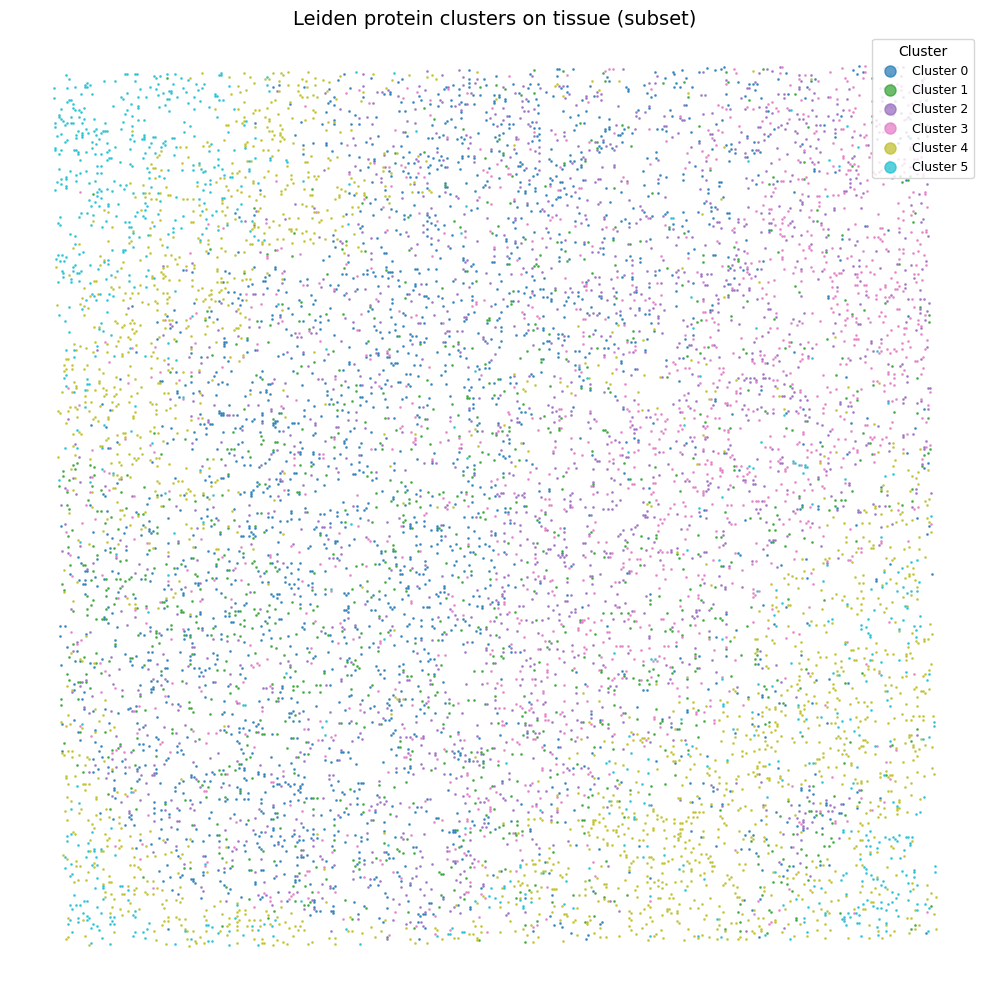

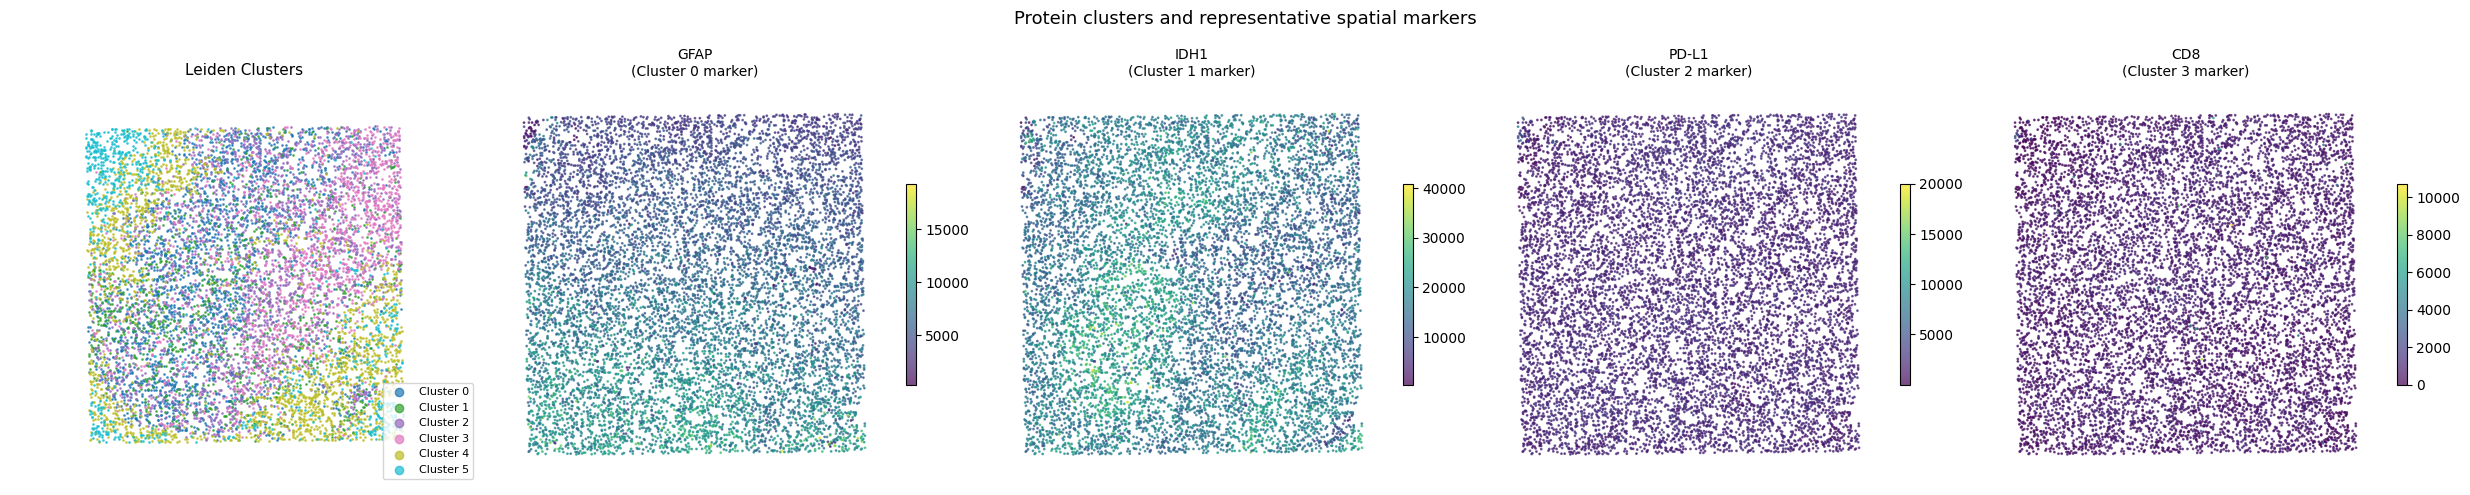

/tmp/ipykernel_536/4054369570.py:98: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_means = df_pro_sub.groupby('cluster').mean()


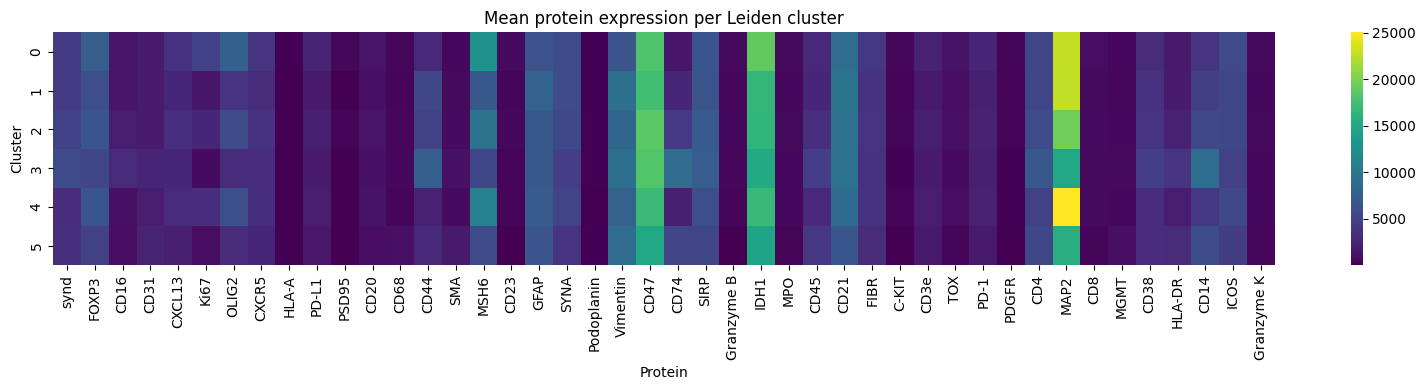

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Get cluster labels and coordinates for subset
cluster_labels = adata_pro_clust.obs['leiden'].values
coords_sub = adata_rna_sub.obs[['pxl_col_in_fullres', 'pxl_row_in_fullres']].values

unique_clusters = sorted(adata_pro_clust.obs['leiden'].unique(), key=lambda x: int(x))
n_clusters = len(unique_clusters)

# Use a qualitative colormap so clusters are visually distinct
cmap = plt.cm.get_cmap('tab10', n_clusters)

# Cluster assignments on tissue
plt.figure(figsize=(10, 10))
for i, cluster in enumerate(unique_clusters):
    mask = cluster_labels == cluster
    plt.scatter(coords_sub[mask, 0], coords_sub[mask, 1],
                c=[cmap(i)],
                s=1,
                alpha=0.7,
                label=f'Cluster {cluster}')

plt.title('Leiden protein clusters on tissue (subset)', fontsize=14)
plt.axis('equal')
plt.axis('off')
plt.legend(markerscale=8, loc='upper right',
           title='Cluster', fontsize=9)
plt.tight_layout()
plt.show()

# Plot 2: One representative protein per cluster
# overlaid on tissue to validate cluster identity
# Pick one biologically meaningful protein per cluster
# Adjust these based on which proteins define each cluster
# in clustermap:
rep_proteins = {
    '0': 'GFAP',      # glial/structural
    '1': 'IDH1',      # tumour
    '2': 'PD-L1',     # immune checkpoint
    '3': 'CD8',       # cytotoxic T cell
}

X_pro_sub = adata_pro_sub.X
X_pro_sub = X_pro_sub.toarray() if hasattr(X_pro_sub, 'toarray') else np.asarray(X_pro_sub)
pro_names = adata_pro_sub.var_names.tolist()

n_proteins = len(rep_proteins)
fig, axes = plt.subplots(1, n_proteins + 1, figsize=(5 * (n_proteins + 1), 5))

# First panel — cluster map
for i, cluster in enumerate(unique_clusters):
    mask = cluster_labels == cluster
    axes[0].scatter(coords_sub[mask, 0], coords_sub[mask, 1],
                    c=[cmap(i)], s=1, alpha=0.7,
                    label=f'Cluster {cluster}')
axes[0].set_title('Leiden Clusters', fontsize=11)
axes[0].axis('equal')
axes[0].axis('off')
axes[0].legend(markerscale=6, fontsize=8)

# Remaining panels — one protein per cluster
for ax, (cluster_id, protein) in zip(axes[1:], rep_proteins.items()):
    if protein not in pro_names:
        print(f"Warning: {protein} not found, skipping")
        continue
    idx = pro_names.index(protein)
    vals = X_pro_sub[:, idx]
    sc = ax.scatter(coords_sub[:, 0], coords_sub[:, 1],
                    c=vals, cmap='viridis', s=1, alpha=0.7)
    plt.colorbar(sc, ax=ax, shrink=0.5)
    ax.set_title(f'{protein}\n(Cluster {cluster_id} marker)', fontsize=10)
    ax.axis('equal')
    ax.axis('off')

plt.suptitle('Protein clusters and representative spatial markers', fontsize=13)
plt.tight_layout()
plt.show()

# Per-cluster mean expression heatmap
# shows what defines each cluster biologically
import pandas as pd
import seaborn as sns

df_pro_sub = pd.DataFrame(X_pro_sub,
                           columns=pro_names,
                           index=adata_pro_sub.obs.index)
df_pro_sub['cluster'] = cluster_labels

cluster_means = df_pro_sub.groupby('cluster').mean()

plt.figure(figsize=(16, 4))
sns.heatmap(cluster_means,
            cmap='viridis',
            xticklabels=True,
            yticklabels=True,
            annot=False)
plt.title('Mean protein expression per Leiden cluster')
plt.xlabel('Protein')
plt.ylabel('Cluster')
plt.tight_layout()
plt.show()

In [ ]:
# Overall mean across all spots
overall_mean = df_pro_sub.drop(columns='cluster').mean()

# Fold change: cluster mean / overall mean
# High value = this protein is higher in this cluster than average
fold_change = cluster_means.div(overall_mean, axis=1)

print("=== Top 5 DISTINCTIVE proteins per cluster (fold change over mean) ===\n")
for cluster_id in fold_change.index:
    top5 = fold_change.loc[cluster_id].sort_values(ascending=False).head(5)
    print(f"Cluster {cluster_id}:")
    for protein, val in top5.items():
        print(f"  {protein:<20} fold change = {val:.2f}x")
    print()

=== Top 5 DISTINCTIVE proteins per cluster (fold change over mean) ===

Cluster 0:
  Granzyme B           fold change = 1.42x
  PSD95                fold change = 1.37x
  C-KIT                fold change = 1.29x
  Podoplanin           fold change = 1.28x
  PDGFR                fold change = 1.27x

Cluster 1:
  CD74                 fold change = 1.54x
  CD16                 fold change = 1.35x
  CD44                 fold change = 1.34x
  synd                 fold change = 1.27x
  CD14                 fold change = 1.22x

Cluster 2:
  CD68                 fold change = 1.11x
  MSH6                 fold change = 1.10x
  Ki67                 fold change = 1.07x
  OLIG2                fold change = 1.02x
  HLA-A                fold change = 0.97x

Cluster 3:
  CD23                 fold change = 1.95x
  PSD95                fold change = 1.64x
  HLA-A                fold change = 1.35x
  PDGFR                fold change = 1.32x
  C-KIT                fold change = 1.28x

Cluster 4:
  MAP2   